In [4]:
import pandas as pd
nutrition_data = pd.read_excel("/Users/saivedhathota/Desktop/batch 8 iomp/datset.xlsx")
nutrition_data.shape
nutrition_data.head()
nutrition_data.tail()
nutrition_data.info()
nutrition_data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8789 entries, 0 to 8788
Data columns (total 77 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Unnamed: 0                   8789 non-null   int64 
 1   name                         8789 non-null   object
 2   serving_size                 8789 non-null   object
 3   calories                     8789 non-null   int64 
 4   total_fat                    8789 non-null   object
 5   saturated_fat                7199 non-null   object
 6   cholesterol                  8789 non-null   object
 7   sodium                       8789 non-null   object
 8   choline                      8789 non-null   object
 9   folate                       8789 non-null   object
 10  folic_acid                   8789 non-null   object
 11  niacin                       8789 non-null   object
 12  pantothenic_acid             8789 non-null   object
 13  riboflavin                   8789

,Unnamed: 0,calories,lucopene
count,8789.000000,8789.000000,8789.0
mean,4394.000000,226.283878,0.0
std,2537.310091,169.862001,0.0
min,0.000000,0.000000,0.0
25%,2197.000000,91.000000,0.0
50%,4394.000000,191.000000,0.0
75%,6591.000000,337.000000,0.0
max,8788.000000,902.000000,0.0


In [9]:
# Clean protein, carbohydrate, fat (remove g,mg,mcg,etc)
# Remove hidden spaces in column names (important)
nutrition_data.columns = nutrition_data.columns.str.strip()

for col in nutrition_data.columns:
    # Skip name column
    if col != 'name':
        # Convert to string first
        nutrition_data[col] = nutrition_data[col].astype(str)
        # Remove all non-numeric characters (mg, mcg, g, spaces etc.)
        nutrition_data[col] = nutrition_data[col].str.replace(r'[^0-9.]', '', regex=True)
        # Convert back to numeric
        nutrition_data[col] = pd.to_numeric(nutrition_data[col], errors='coerce')
        
nutrition_data

,Unnamed: 0,name,serving_size,calories,total_fat,saturated_fat,cholesterol,sodium,choline,folate,...,fat,saturated_fatty_acids,monounsaturated_fatty_acids,polyunsaturated_fatty_acids,fatty_acids_total_trans,alcohol,ash,caffeine,theobromine,water
0,0,Cornstarch,100,381,0.1,NaN,0,9.0,0.4,0.0,...,0.05,0.009,0.016,0.025,0.0,0.0,0.09,0.0,0.0,8.32
1,1,"Nuts, pecans",100,691,72.0,6.2,0,0.0,40.5,22.0,...,71.97,6.180,40.801,21.614,0.0,0.0,1.49,0.0,0.0,3.52
2,2,"Eggplant, raw",100,25,0.2,NaN,0,2.0,6.9,22.0,...,0.18,0.034,0.016,0.076,0.0,0.0,0.66,0.0,0.0,92.30
3,3,"Teff, uncooked",100,367,2.4,0.4,0,12.0,13.1,0.0,...,2.38,0.449,0.589,1.071,0.0,0.0,2.37,0.0,0.0,8.82
4,4,"Sherbet, orange",100,144,2.0,1.2,1,46.0,7.7,4.0,...,2.00,1.160,0.530,0.080,1.0,0.0,0.40,0.0,0.0,66.10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8784,8784,"Beef, raw, all grades, trimmed to 0"" fat, sepa...",100,125,3.5,1.4,62,54.0,64.5,4.0,...,3.50,1.353,1.554,0.244,62.0,0.0,1.11,0.0,0.0,72.51
8785,8785,"Lamb, cooked, separable lean only, composite o...",100,206,8.9,3.9,109,50.0,0.0,0.0,...,8.86,3.860,3.480,0.520,109.0,0.0,1.60,0.0,0.0,59.95
8786,8786,"Lamb, raw, separable lean and fat, composite o...",100,277,23.0,12.0,78,39.0,0.0,1.0,...,22.74,11.570,8.720,0.980,78.0,0.0,0.92,0.0,0.0,59.80
8787,8787,"Beef, raw, all grades, trimmed to 0"" fat, sepa...",100,121,3.0,1.1,60,53.0,64.2,4.0,...,3.04,1.086,1.266,0.233,60.0,0.0,1.10,0.0,0.0,73.43


In [11]:

#drop unnamed
nutrition_data.drop('Unnamed: 0', axis=1, inplace=True)


In [13]:
nutrition_data.drop('saturated_fat', axis=1, inplace=True)


In [15]:
nutrition_data.columns

Index(['name', 'serving_size', 'calories', 'total_fat', 'cholesterol',
       'sodium', 'choline', 'folate', 'folic_acid', 'niacin',
       'pantothenic_acid', 'riboflavin', 'thiamin', 'vitamin_a',
       'vitamin_a_rae', 'carotene_alpha', 'carotene_beta',
       'cryptoxanthin_beta', 'lutein_zeaxanthin', 'lucopene', 'vitamin_b12',
       'vitamin_b6', 'vitamin_c', 'vitamin_d', 'vitamin_e', 'tocopherol_alpha',
       'vitamin_k', 'calcium', 'copper', 'irom', 'magnesium', 'manganese',
       'phosphorous', 'potassium', 'selenium', 'zink', 'protein', 'alanine',
       'arginine', 'aspartic_acid', 'cystine', 'glutamic_acid', 'glycine',
       'histidine', 'hydroxyproline', 'isoleucine', 'leucine', 'lysine',
       'methionine', 'phenylalanine', 'proline', 'serine', 'threonine',
       'tryptophan', 'tyrosine', 'valine', 'carbohydrate', 'fiber', 'sugars',
       'fructose', 'galactose', 'glucose', 'lactose', 'maltose', 'sucrose',
       'fat', 'saturated_fatty_acids', 'monounsaturated_fatt

In [17]:
# numeric columns
numeric_columns=nutrition_data.select_dtypes(include="number")
numeric_columns

,serving_size,calories,total_fat,cholesterol,sodium,choline,folate,folic_acid,niacin,pantothenic_acid,...,fat,saturated_fatty_acids,monounsaturated_fatty_acids,polyunsaturated_fatty_acids,fatty_acids_total_trans,alcohol,ash,caffeine,theobromine,water
0,100,381,0.1,0,9.0,0.4,0.0,0.0,0.000,0.000,...,0.05,0.009,0.016,0.025,0.0,0.0,0.09,0.0,0.0,8.32
1,100,691,72.0,0,0.0,40.5,22.0,0.0,1.167,0.863,...,71.97,6.180,40.801,21.614,0.0,0.0,1.49,0.0,0.0,3.52
2,100,25,0.2,0,2.0,6.9,22.0,0.0,0.649,0.281,...,0.18,0.034,0.016,0.076,0.0,0.0,0.66,0.0,0.0,92.30
3,100,367,2.4,0,12.0,13.1,0.0,0.0,3.363,0.942,...,2.38,0.449,0.589,1.071,0.0,0.0,2.37,0.0,0.0,8.82
4,100,144,2.0,1,46.0,7.7,4.0,0.0,0.063,0.224,...,2.00,1.160,0.530,0.080,1.0,0.0,0.40,0.0,0.0,66.10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8784,100,125,3.5,62,54.0,64.5,4.0,0.0,6.422,0.356,...,3.50,1.353,1.554,0.244,62.0,0.0,1.11,0.0,0.0,72.51
8785,100,206,8.9,109,50.0,0.0,0.0,0.0,7.680,0.580,...,8.86,3.860,3.480,0.520,109.0,0.0,1.60,0.0,0.0,59.95
8786,100,277,23.0,78,39.0,0.0,1.0,0.0,6.550,0.520,...,22.74,11.570,8.720,0.980,78.0,0.0,0.92,0.0,0.0,59.80
8787,100,121,3.0,60,53.0,64.2,4.0,0.0,6.720,0.355,...,3.04,1.086,1.266,0.233,60.0,0.0,1.10,0.0,0.0,73.43


In [19]:

#categorical culumns
categorical_columns=nutrition_data.select_dtypes(exclude="number")
categorical_columns


,name
0,Cornstarch
1,"Nuts, pecans"
2,"Eggplant, raw"
3,"Teff, uncooked"
4,"Sherbet, orange"
...,...
8784,"Beef, raw, all grades, trimmed to 0"" fat, sepa..."
8785,"Lamb, cooked, separable lean only, composite o..."
8786,"Lamb, raw, separable lean and fat, composite o..."
8787,"Beef, raw, all grades, trimmed to 0"" fat, sepa..."


In [21]:

#nullvalues
nullvalues = (nutrition_data.isna().sum())
nullvalues

name            0
serving_size    0
calories        0
total_fat       0
cholesterol     0
               ..
alcohol         0
ash             0
caffeine        0
theobromine     0
water           0
Length: 75, dtype: int64

In [23]:

# Text Processing for Food Names
import re
def clean_text(text):
    text = str(text).lower()              # convert to lowercase
    text = re.sub(r'[^a-zA-Z ]', '', text) # remove numbers and symbols
    text = text.strip()                   # remove extra spaces
    return text

print(nutrition_data['name'].head(10))
print(nutrition_data.columns)
print(nutrition_data.head())
nutrition_data['name'] = nutrition_data['name'].apply(clean_text)
print(nutrition_data['name'].head(10))

0            Cornstarch
1          Nuts, pecans
2         Eggplant, raw
3        Teff, uncooked
4       Sherbet, orange
5      Cauliflower, raw
6      Taro leaves, raw
7     Lamb, raw, ground
8     Cheese, camembert
9    Vegetarian fillets
Name: name, dtype: object
Index(['name', 'serving_size', 'calories', 'total_fat', 'cholesterol',
       'sodium', 'choline', 'folate', 'folic_acid', 'niacin',
       'pantothenic_acid', 'riboflavin', 'thiamin', 'vitamin_a',
       'vitamin_a_rae', 'carotene_alpha', 'carotene_beta',
       'cryptoxanthin_beta', 'lutein_zeaxanthin', 'lucopene', 'vitamin_b12',
       'vitamin_b6', 'vitamin_c', 'vitamin_d', 'vitamin_e', 'tocopherol_alpha',
       'vitamin_k', 'calcium', 'copper', 'irom', 'magnesium', 'manganese',
       'phosphorous', 'potassium', 'selenium', 'zink', 'protein', 'alanine',
       'arginine', 'aspartic_acid', 'cystine', 'glutamic_acid', 'glycine',
       'histidine', 'hydroxyproline', 'isoleucine', 'leucine', 'lysine',
       'methionine',

In [25]:

#Text Embedding (TF-IDF)
from sklearn.feature_extraction.text import TfidfVectorizer
# Convert food names into numerical vectors
tfidf = TfidfVectorizer()
text_features = tfidf.fit_transform(nutrition_data['name'])
print(text_features.shape)


(8789, 3182)


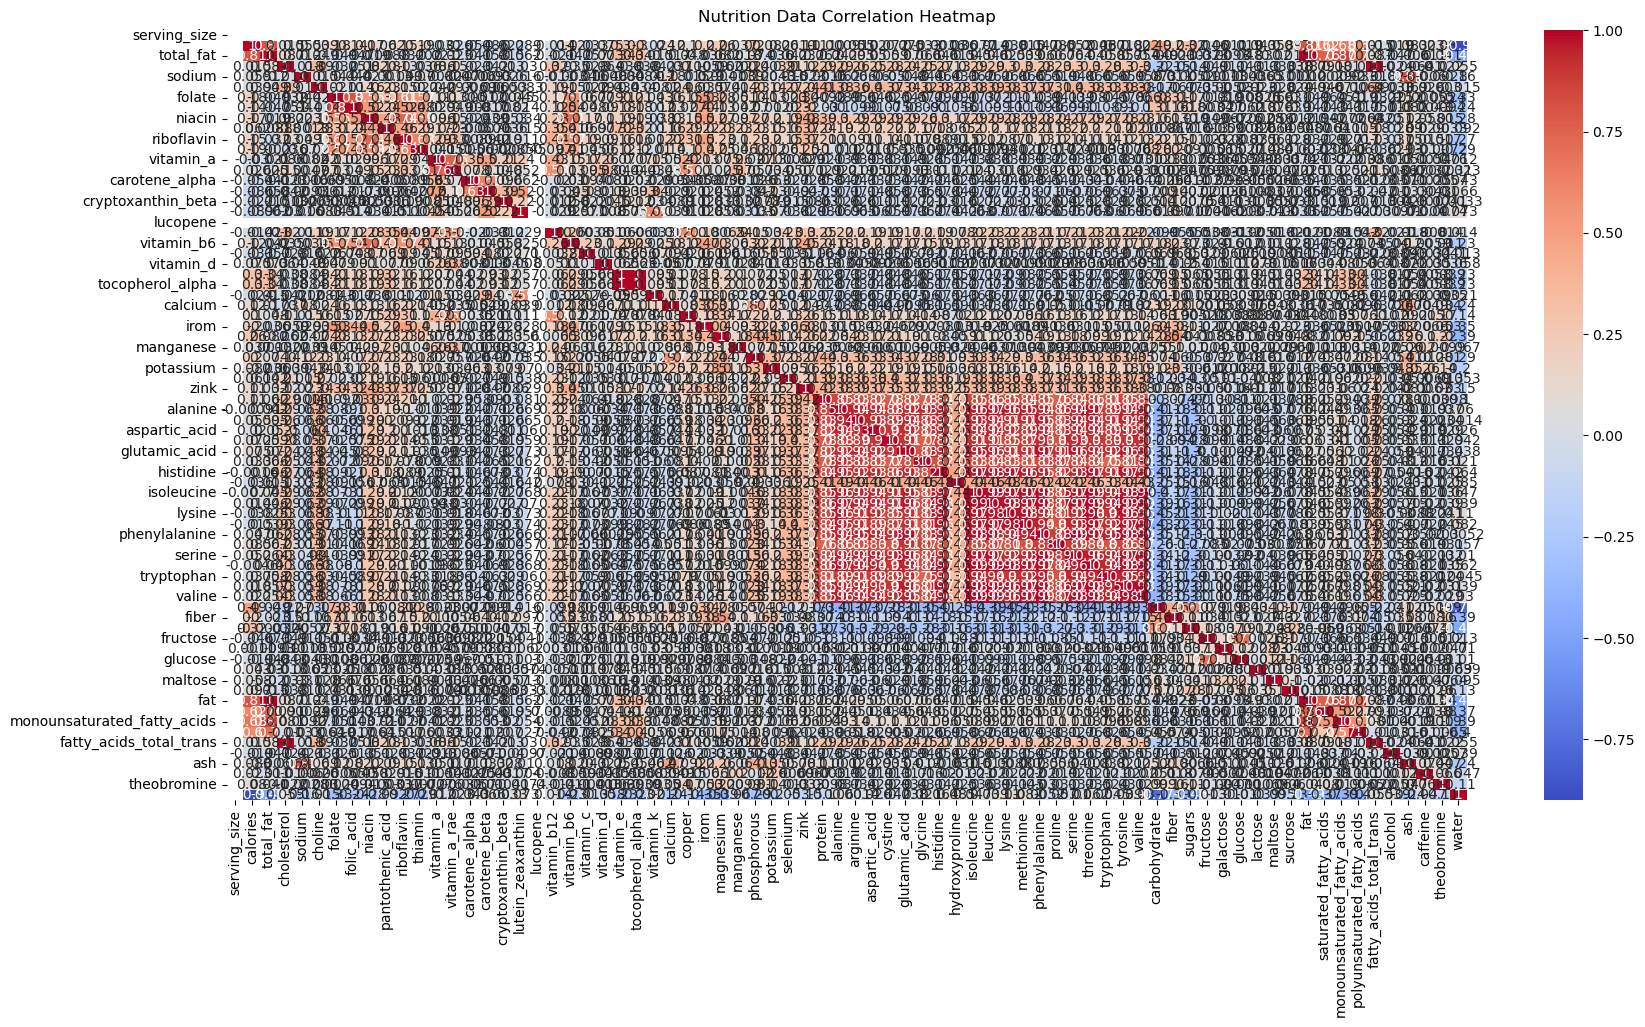

In [27]:
# Correlation Heatmap
import matplotlib.pyplot as plt
import seaborn as sns
# Select only numeric columns
numeric_data = nutrition_data.select_dtypes(include=['number'])
# Correlation Heatmap
plt.figure(figsize=(20,10))
sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm')
plt.title("Nutrition Data Correlation Heatmap")
plt.show()


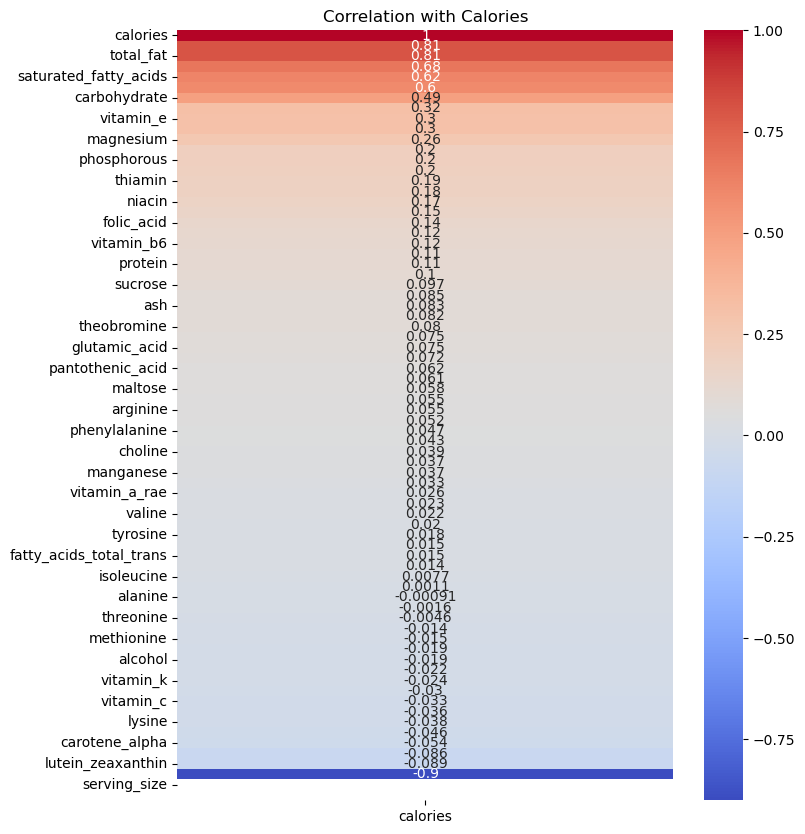

In [29]:
# Correlation with calories
plt.figure(figsize=(8,10))
sns.heatmap(
    numeric_data.corr()[['calories']].sort_values(by='calories', ascending=False),
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation with Calories")
plt.show()


In [33]:
#  Create calorie category
nutrition_data['calorie_category'] = pd.cut(
    nutrition_data['calories'],
    bins=[0, 100, 300, 1000],
    labels=['Low', 'Medium', 'High']
)

# Encode target (VERY IMPORTANT)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(nutrition_data['calorie_category'])

# Numeric features (REMOVE name, calories, target)
X_numeric = nutrition_data.drop(['name', 'calories', 'calorie_category'], axis=1)

#Scale numeric features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_numeric_scaled = scaler.fit_transform(X_numeric)

# Combine text + numeric features
import numpy as np
X = np.hstack((text_features.toarray(), X_numeric_scaled))

# Check shapes
print("Final Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Final Feature Shape: (8789, 3255)
Target Shape: (8789,)


In [63]:

# train_test  with random forest 
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
rf_model = RandomForestRegressor()
rf_model.fit(X_train,y_train)

print("Model Score:", rf_model.score(X_test,y_test))


Model Score: 0.9394155425009565


In [36]:
# train_test with svm 
from sklearn.svm import SVR
# SVM Regression Model
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
svm_model = SVR(kernel='rbf')

svm_model.fit(X_train, y_train)

print("SVM Model Score:", svm_model.score(X_test, y_test))

SVM Model Score: 0.7550632712603838


In [65]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Random Forest predictions
rf_pred = rf_model.predict(X_test)

print("Random Forest Evaluation")
print("MAE:", mean_absolute_error(y_test, rf_pred))
print("MSE:", mean_squared_error(y_test, rf_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("R2 Score:", r2_score(y_test, rf_pred))

Random Forest Evaluation
MAE: 0.060563139931740624
MSE: 0.044267747440273036
RMSE: 0.21039901958011362
R2 Score: 0.9394155425009565


In [41]:
svm_pred = svm_model.predict(X_test)

print("SVM Evaluation")
print("MAE:", mean_absolute_error(y_test, svm_pred))
print("MSE:", mean_squared_error(y_test, svm_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, svm_pred)))
print("R2 Score:", r2_score(y_test, svm_pred))

SVM Evaluation
MAE: 0.24485178050375606
MSE: 0.17896994863514595
RMSE: 0.42304839987304754
R2 Score: 0.7550632712603838


In [43]:
print("Random Forest R2:", r2_score(y_test, rf_pred))
print("SVM R2:", r2_score(y_test, svm_pred))

Random Forest R2: 0.9389314753113973
SVM R2: 0.7550632712603838


In [45]:
import pandas as pd

results = pd.DataFrame({
    "Actual Calories": y_test[:10],
    "Predicted Calories": rf_pred[:10]
})

print(results)

   Actual Calories  Predicted Calories
0                2                2.00
1                0                0.00
2                1                1.00
3                2                2.00
4                2                2.00
5                1                1.00
6                1                1.00
7                1                1.02
8                1                1.00
9                0                0.00


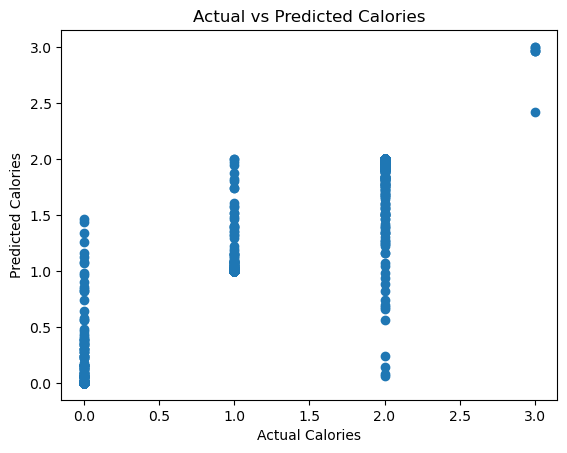

In [47]:
import matplotlib.pyplot as plt

plt.scatter(y_test, rf_pred)
plt.xlabel("Actual Calories")
plt.ylabel("Predicted Calories")
plt.title("Actual vs Predicted Calories")
plt.show()

In [93]:
importance = rf_model.feature_importances_

import pandas as pd
feat_imp = pd.DataFrame({
    "Feature": X_numeric.columns,
    "Importance": importance[-len(X_numeric.columns):]
}).sort_values(by="Importance", ascending=False)

print(feat_imp)

                  Feature  Importance
72                  water    0.093240
54           carbohydrate    0.042429
63                    fat    0.038622
1               total_fat    0.038395
64  saturated_fatty_acids    0.036736
..                    ...         ...
71            theobromine    0.000805
60                lactose    0.000734
58              galactose    0.000514
17               lucopene    0.000000
0            serving_size    0.000000

[73 rows x 2 columns]


In [73]:
import pickle

with open("nutrition_model.pkl", "wb") as f:
    pickle.dump(rf_model, f)

In [75]:
with open("nutrition_model.pkl", "rb") as f:
    loaded_model = pickle.load(f)

print(type(loaded_model))   # should be RandomForestRegressor
print(loaded_model.predict(X_test[:5]))

<class 'sklearn.ensemble._forest.RandomForestRegressor'>
[2. 0. 1. 2. 2.]
